# Análise de Séries Temporais — Jogadores Semanais de Counter-Strike 2

**Enunciado:** *"Apresentar uma análise de dados real"*

---

## Sumário

1. **Introdução** — descrição da base, importação e filtro 2016–2025
2. **Análise exploratória** — gráfico da série, descritivas, ACF/PACF, decomposição STL
3. **Estacionariedade** — testes ADF & KPSS, diferenciação
4. **Detecção de outliers** — `tsoutliers`
5. **Modelagem** — leitura dos gráficos ACF/PACF e `auto.arima`
6. **Diagnóstico dos resíduos** — ACF, Ljung-Box, normalidade, homocedasticidade
7. **Previsão** — h passos à frente com intervalos de confiança
8. **Validação** — janela treino/teste e métricas de erro


---

## 1: Introdução

A análise de séries temporais é um método estatístico bem eficiente para dados levantados ao longo de um determinado período de tempo, permitindo identificar padrões, tendências e sazonalidades.

Por isso, para esse trabalho, iremos realizar uma análise completa de uma série temporal, desde as medidas descritivas, decomposição STL, identificação de outliers até ajuste de modelos ARIMA e previsões.

A série escolhida para esta análise é o **número semanal de jogadores de Counter-Strike 2** (antes da transição para CS2 em 2023, era conhecido como CS:GO — *Counter-Strike: Global Offensive*), um jogo de tiro multiplayer da plataforma Steam, na qual Counter Strike 2 se encontra disponível para download. Os dados foram extraídos da plataforma de terceiros "SteamDB", que registra o número de jogadores ativos por dia.

Para uma análise mais focada e precisa, a série foi reduzida/filtrada entre **1 de janeiro de 2016** e **31 de dezembro de 2025**, e os registros diários foram agregados em médias **semanais** (semanas iniciando às segundas-feiras).

---

In [155]:
library(dplyr)
library(lubridate)
library(tseries)
library(forecast)
library(lmtest)
library(tsoutliers)



In [156]:
cs <- read.csv("counter_strike.csv", sep = ';')

cs_semanal <- cs |>
  dplyr::mutate(semana = floor_date(as.Date(DateTime),
                                     unit       = "week",
                                     week_start = 1)) |>
  dplyr::filter(semana >= as.Date("2016-01-01"),
                semana <= as.Date("2025-12-31")) |>
  dplyr::group_by(semana) |>
  dplyr::summarise(jogadores = mean(Players, na.rm = TRUE))

cat("Dimensões:", nrow(cs_semanal), "semanas\n")
head(cs_semanal)


Dimensões: 522 semanas


semana,jogadores
<date>,<dbl>
2016-01-04,628781.0
2016-01-11,597923.1
2016-01-18,615375.0
2016-01-25,613932.7
2016-02-01,610113.6
2016-02-08,620624.4


In [157]:
serie <- ts(cs_semanal$jogadores,
            start     = c(2016, 1),
            frequency = 52)

cat("Início:", start(serie), "| Fim:", end(serie),
    "| Observações:", length(serie), "\n")


Início: 2016 1 | Fim: 2026 2 | Observações: 522 


## 2: Análise exploratória

Antes de qualquer modelagem, com a série apresentada, começaremos, agora, uma breve análise descritiva da série a fim de entender o comportamento visual da série de jogadores de Counter Strike 2 e caracterizar sua estrutura.

Para isso, iremos primeiramente visualizar a série, no período delimitado anterior.

### 2.1 Gráfico da série

<img src="2_1_serie.png" alt="2_1_serie" width="500" height = "500"/>

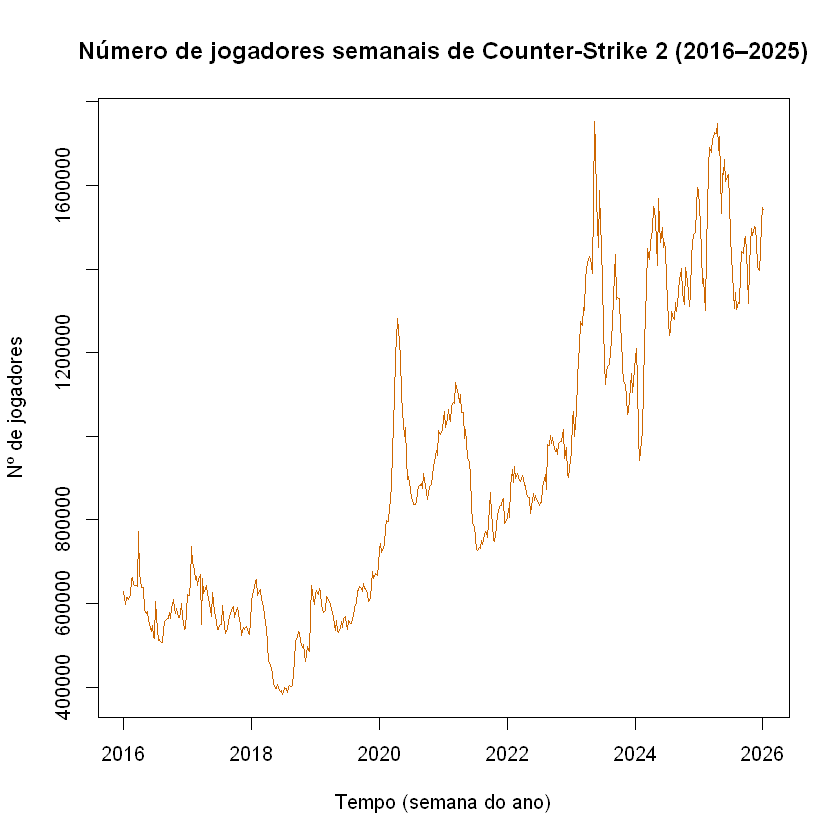

In [158]:
plot(serie,
     main = "Número de jogadores semanais de Counter-Strike 2 (2016–2025)",
     xlab = "Tempo (semana do ano)",
     ylab = "Nº de jogadores",
     col  = "darkorange3")


### 2.2 Estatísticas descritivas

```
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 382055  599685  849719  916332 1207915 1753420 
 
```

Analisando visualmente a série, percebemos que ela possui uma tendência crescente bem evidente, com poucos picos decrescentes que mudem o crescimento da série. Esse comportamento se dá devido ao jogo ser multijogador, ou seja, não possui fases e mantém as pessoas jogando por mais tempo.

Além disso, há vários picos evidentes ao longo do tempo, provavelmente indicativos de eventos ou atualizações no jogo para aumentar o número de jogadores.

In [159]:
summary(serie)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 382055  599685  849719  916332 1207915 1753420 

### 2.3 Decomposição STL

Para verificar melhor a tendência, tanto quanto outros componentes da série, iremos decompô-lá por meio da função $\texttt{stl}$, a qual decompõe a série em:

$$
X_t = T_t + S_t + R_t, 
$$

em que $T_t$ é o componente de tendência, $S_t$ é o componente sazonal e $R_t$ é o componente residual.

<img src="2_decomposicao.png" alt="2_decomposicao" width="500" height = "500"/>

Com a série decomposta, podemos analisar seus componentes mais detalhadamente.

A **tendência** já age conforme o esperado, com um claro padrão crescente por todo o tempo analisado. Já a **sazonalidade** também é bem evidente, apresentando pico de jogadores em todo começo de ano, período de férias ou recesso, o que aumenta o número de jogadores.

Por fim, temos os **resíduos**, o restante da série após retirarmos a tendência e a sazonalidade. Exceto por picos em 2020 (pandemia) e 2023-2024 (lançamento do CS2), os resíduos não apresentam padrão evidente, oscilando em torno de série com o passar do tempo.

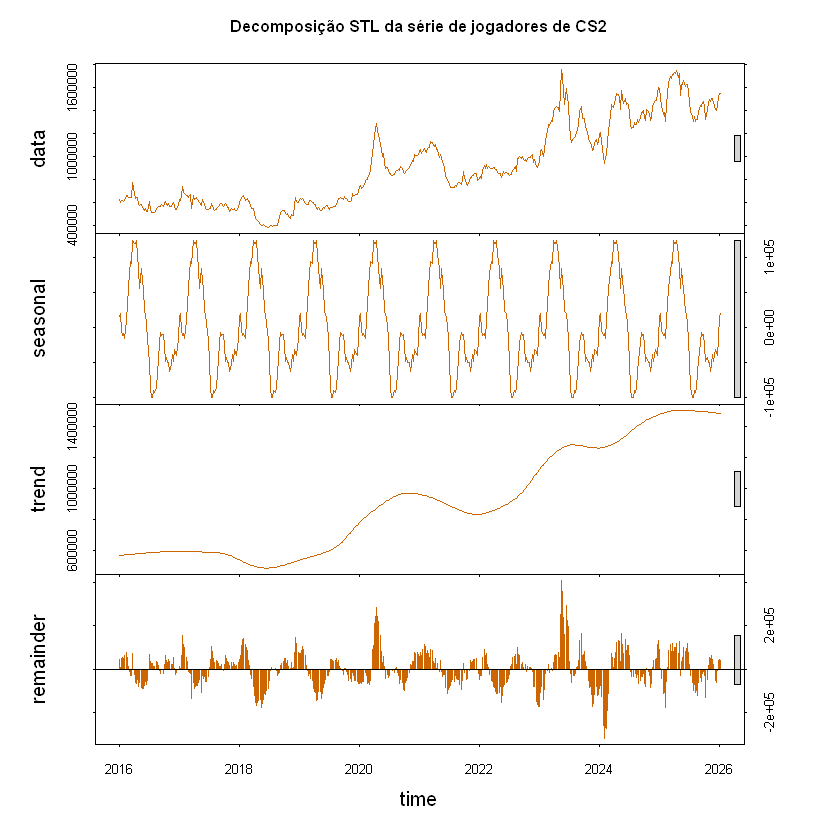

In [160]:
decomp <- stl(serie, s.window = "periodic")
plot(decomp,
     main = "Decomposição STL da série de jogadores de CS2",
     col  = "darkorange3")


### 2.4 Gráficos ACF e PACF

A última análise a ser feita nessa etapa será avaliar a presença de autocorrelação e autocorrelação parcial, ferramentas para identificar a dependência temporal da série.

<img src="2_acf_pacf.png" alt="2_acf_pacf" width="500" height = "500"/>

Analisando a autocorrelação, há um indicativo forte de tendência, uma vez que os lags decaem de forma lenta, demorando a entrar no intervalo de confiança. Isso é uma evidência para diferenciarmos a série, passo que será feito na próxima etapa.

Já a autocorrelação parcial mostra um pico do lag 1 muito próximo de 1 decaindo rapidamente para dentro do intervalo de confiança logo no próximo lag, evidenciando que a série possa ser modelado futuramente como um modelo autoregressivo de ordem 1.

---

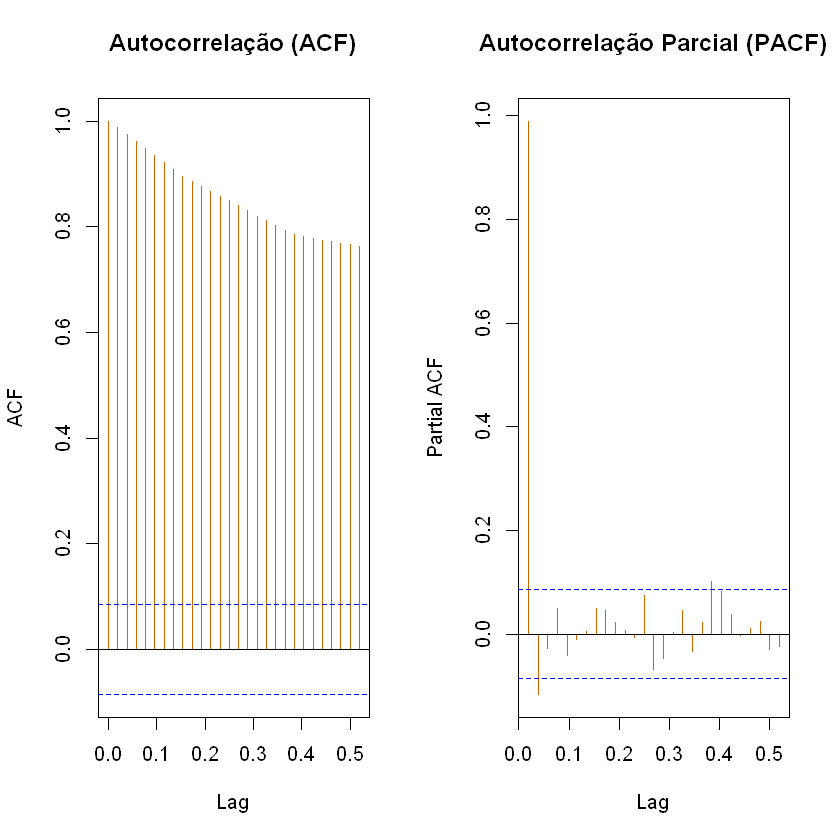

In [161]:
par(mfrow = c(1, 2))
acf (serie, main = "Autocorrelação (ACF)",         col = "darkorange3")
pacf(serie, main = "Autocorrelação Parcial (PACF)", col = "darkorange3")
par(mfrow = c(1, 1))


## 3: Estacionariedade

Como analisado na última etapa, é claro que a série utilizada não é estacionária, ou seja, sua média não se mantém constante ao longo do tempo.

Além da decomposição e gráfico ACF, uma maneira mais precisa de verificar estacionariedade é por meio de dois testes estatísticos. O teste Dickey-Fuller Aumentado (ADF) e o teste KPSS.

Os teste ADF e KPSS têm como hipóteses:

| Teste | $H_0$ | $H_1$ |
|---|---|---|
| **ADF** (*Augmented Dickey-Fuller*) | Há raiz unitária (não-estacionária) | Não há raiz unitária (estacionária) |
| **KPSS** | Série estacionária | Série não-estacionária |

### 3.1 Testes na série original

Realizando os testes:

```
	Augmented Dickey-Fuller Test

data:  serie
Dickey-Fuller = -3.5364, Lag order = 8, p-value = 0.03881
alternative hypothesis: stationary
```

```
	KPSS Test for Level Stationarity

data:  serie
KPSS Level = 6.286, Truncation lag parameter = 6, p-value = 0.01
```

O p-valor do teste ADF resultou em aproximadamente 0,038, ou seja, rejeitamos $H_0$ e temos evidências que a série é estacionária.

Entretanto, o teste KPSS resultou em um p-valor menor que 0,01, ou seja, esse teste já indica que a série não é estacionária.

Dado a divergência dos testes e o fato dos gráficos anteriores indicarem com clareza a tendência crescente da série, o caminho é diferenciar a série e refazer os testes.

Iremos fazer, então, uma **diferenciação** de ordem 1 na série, isto é,

$$
X_t = X_t - X_{t-1}
$$

In [162]:
adf.test(serie)   # H0: não-estacionária
kpss.test(serie)  # H0: estacionária


	Augmented Dickey-Fuller Test

data:  serie
Dickey-Fuller = -3.5364, Lag order = 8, p-value = 0.03881
alternative hypothesis: stationary


Warning message in kpss.test(serie):
"p-value smaller than printed p-value"



	KPSS Test for Level Stationarity

data:  serie
KPSS Level = 6.286, Truncation lag parameter = 6, p-value = 0.01


### 3.2 Diferenciação de ordem 1

A diferenciação de ordem 1 remove a tendência linear ao calcular:

<img src="3_diff.png" alt="3_diff" width="500" height = "500"/>
 
Percebemos, analisando o gráfico da série diferenciada, que após uma diferenciação a série se tornou bem mais estacionária do que a anterior, com indícios de que a média se tornou constante.

Para confirmar a suspeita de estacionariedade, realizaremos os teste ADF e KPSS novamente, juntamente com os gráficos de ACF e PACF.

```
	Augmented Dickey-Fuller Test

data:  serie_diff
Dickey-Fuller = -8.6564, Lag order = 8, p-value = 0.01
alternative hypothesis: stationary
```

```
	KPSS Test for Level Stationarity

data:  serie_diff
KPSS Level = 0.043643, Truncation lag parameter = 6, p-value = 0.1
```

Uma vez que ambos os testes indicam que a série se tornou estacionária e o gráfico ACF mostra uma queda brusca do lag 0 ao lag 1, comportamento esperado em tendência constante, temos evidências suficientes para concluir que a série dos jogadores semanais de CS2 se torna estacionária após uma diferenciação.

---

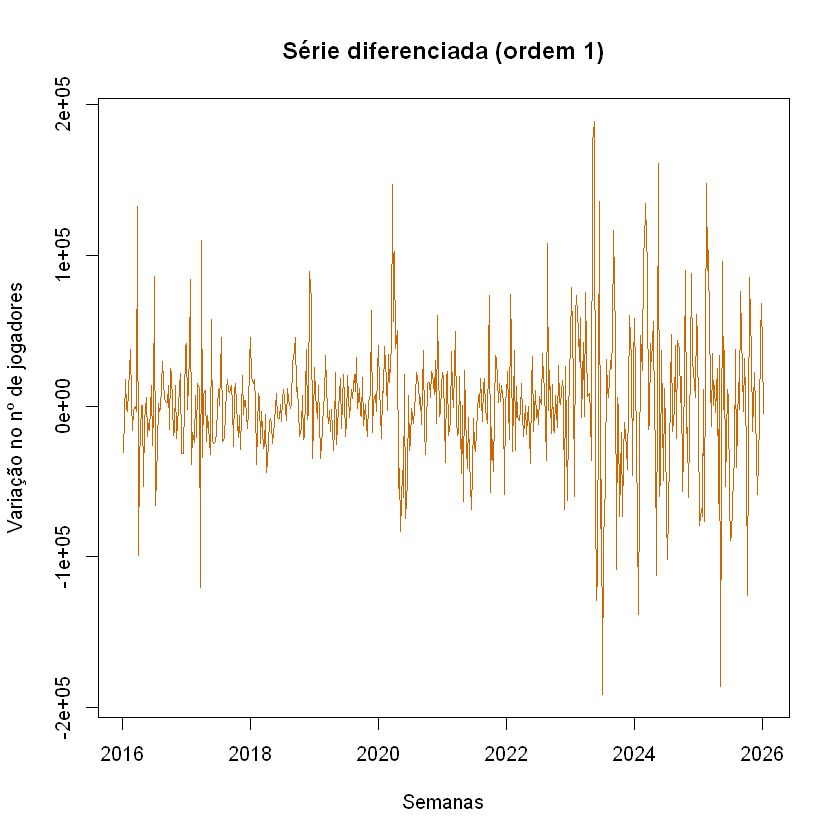

In [163]:
serie_diff <- diff(serie)

plot(serie_diff,
     main = "Série diferenciada (ordem 1)",
     xlab = "Semanas",
     ylab = "Variação no nº de jogadores",
     col  = "darkorange3")

In [164]:
adf.test(serie_diff)
kpss.test(serie_diff)

Warning message in adf.test(serie_diff):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  serie_diff
Dickey-Fuller = -8.6564, Lag order = 8, p-value = 0.01
alternative hypothesis: stationary


Warning message in kpss.test(serie_diff):
"p-value greater than printed p-value"



	KPSS Test for Level Stationarity

data:  serie_diff
KPSS Level = 0.043643, Truncation lag parameter = 6, p-value = 0.1


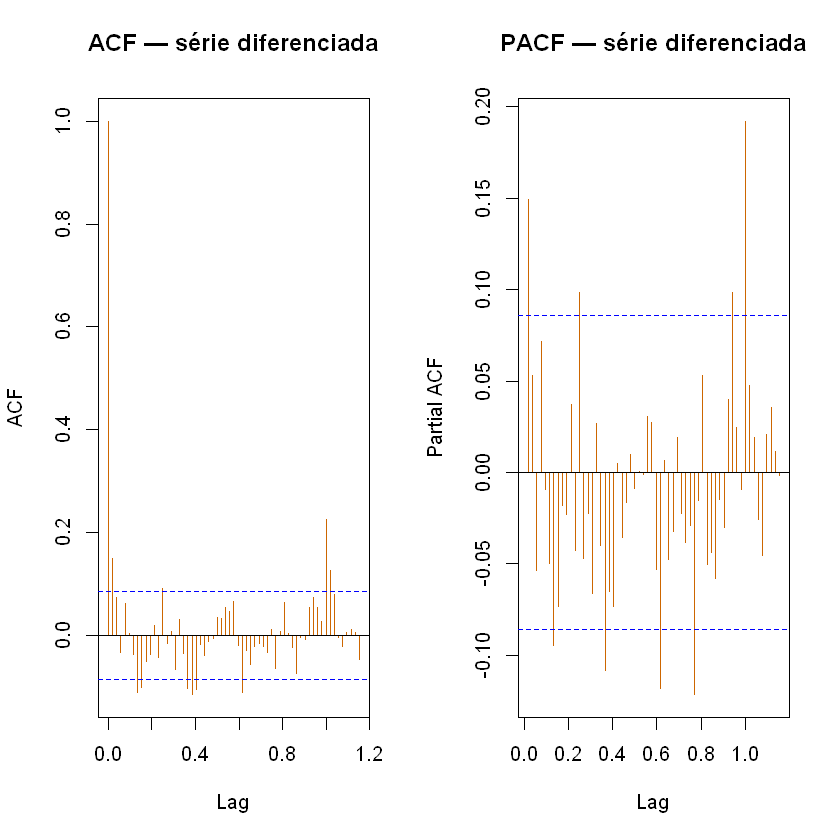

In [165]:
par(mfrow = c(1, 2))
acf (serie_diff, main = "ACF — série diferenciada",  col = "darkorange3", lag.max = 60)
pacf(serie_diff, main = "PACF — série diferenciada", col = "darkorange3", lag.max = 60)
par(mfrow = c(1, 1))

## 4. Detecção de outliers


Antes de ajustar o modelo, identificamos possíveis outliers com a função `tsoutliers` do pacote `forecast`. Ela detecta automaticamente observações atípicas — como *Additive Outliers* (AO), *Level Shifts* (LS) e *Transient Changes* (TC) — e sugere valores de substituição.

In [166]:
library(tsoutliers)
#outliers3 <- tso(serie)

outliers3 <- data.frame(  # fixando outliers sem ter que rodar de novo o pacote tsoutliers
  type = c("LS","TC","LS"),
  ind  = c(220,384,391),
  stringsAsFactors = FALSE
)
dummies <- outliers.effects(outliers3, n = length(serie))

\textbf{Interpretação dos outliers:}

\textbf{Primeiro LS (posição 220 -- Março/2020)}: A mudança permanente no nível da série coincide com o início das medidas de lockdown global decorrentes da pandemia de COVID-19. A classificação como Level Shift (e não como AO) é tecnicamente acertada, pois o isolamento social não gerou um pico passageiro, mas sim uma mudança estrutural no comportamento do consumidor, elevando de forma duradoura a base de espectadores e jogadores ativos devido à adoção massiva do entretenimento digital. A função \texttt{tso} nos diz que um impacto +376.735 jogadores, isso significa que a pandemia elevou o patamar de jogadores de forma permanente.

\textbf{TC (Índice 384 -- Maio/2023)}: Este ponto coincide com as finais do \textit{BLAST.tv Paris Major 2023}, (\textit{Major} é o maior campeonato oficial do jogo) o último Major da história do CS:GO antes da transição para o CS2. A classificação como Temporary Change é coerente com a natureza de um evento pontual de grande apelo midiático: observamos um pico expressivo de engajamento naquela semana específica, cujo efeito, embora intenso, dissipou-se gradualmente nas semanas seguintes, retornando à trajetória de equilíbrio anterior (ou à nova trajetória, como veremos a seguir). O impacto foi de +248.359 jogadores temporariamente.

\textbf{Segundo LS (Índice 391 -- Julho/2023)}: Este é o ponto mais interessante da análise. Aproximadamente dois meses após o Major, detectamos outro Level Shift positivo e permanente. Esse fenômeno pode ser interpretado como o ``efeito legado'' do campeonato. É plausível que o lançamento do CS2 (anunciado para o setembro de 2023) e o enorme sucesso do Major tenham atraído uma leva definitiva de novos jogadores e espectadores que, diferentemente do pico agudo de maio, se consolidaram na comunidade, elevando o patamar mínimo de atividade da série de forma estrutural. O impacto é +272.742 jogadores de forma permanente.

As estatísticas t associadas a cada outlier (variando de 5,15 a 13,99) superam amplamente o valor crítico usual ($\vert t \vert > 2$), confirmando a relevância desses choques para a dinâmica da série. Incluir esses efeitos apenas como ``pontos a serem monitorados'' (como sugerido na análise preliminar) pode não ser suficiente. Posteriormente, na etapa de modelagem, uma opção é utilizaremos os parâmetros gerados pelo tso para construir variáveis de intervenção (dummies permanentes para os LS e com decaimento para o TC) que serão inseridas como regressoras externas (via argumento xreg da auto.arima). Isso poderia evitar que os outliers distorçam a estimativas dos parâmetros do modelo.

## 5. Modelagem

Após analisar os componentes da série e detectar os outliers, podemos, enfim, ajustar um modelo apropriado para a nossa série temporal.

Podemos encontrar o modelo de duas maneiras diferentes: manualmente, analisando os gráficos ACF e PACF, ou pela função $\texttt{auto.arima}$, que ajusta o melhor modelo ARIMA encontrando aquele com o menor BIC, critério muito usado em seleção de modelos.

<img src="5_acf_pacf.png" alt="5_acf_pacf" width="500" height = "500"/>


Em primeiro lugar, vale lembrar que esses gráficos ACF e PACF são optidos após a diferenciação de ordem 1 da série. Logo, teremos $d=1$ como parâmetro do modelo ARIMA.

Analisando o gráfico PACF, percebe-se que, após o lag 1, o próximo lag decai rapidamente para o intervalo de confiança. Com isso, um valor possível para o parâmetro autoregressivo seria $p =1$.

Agora, pelo gráfico ACF, percebe-se que o lag 1 apresenta-se para fora do intervalo de confiança e o lag 2 está em cima do tracejado, ou seja, no limiar do IC. Assim, um valor para o parâmetro de médias móveis seria $q=1$ ou $q=2$.

Porém, é válido perceber que ambos os gráficos apresentam um comportamente sazonal a cada um ano, de acordo com a escala transformada dos gráficos. Desse modo, uma diferença sazonal de 52 semanas, isto é, um ano, seria ideal para remover a sazonalidade.

### 5.1 Seleção automática com `auto.arima`

Encontrando o melhor modelo ARIMA pelo função $\texttt{auto.arima}$, percebemos que aquele com menor BIC indica que

$$
X_t \sim ARIMA(1,1,2)(0,0,1)[52]
$$ 

é o melhor modelo, confirmando o ajuste manual pelos gráficos. Além disso, em R adicionamos um parâmetro "xreg" para considerar os efeitos de outliers.

**Resultado:** O modelo selecionado é o $\text{SARIMA}(1,1,2)(0,0,1)_{52}$, confirmando a leitura manual dos gráficos. A componente sazonal de médias móveis de ordem 1 captura o padrão anual identificado na decomposição STL.

---


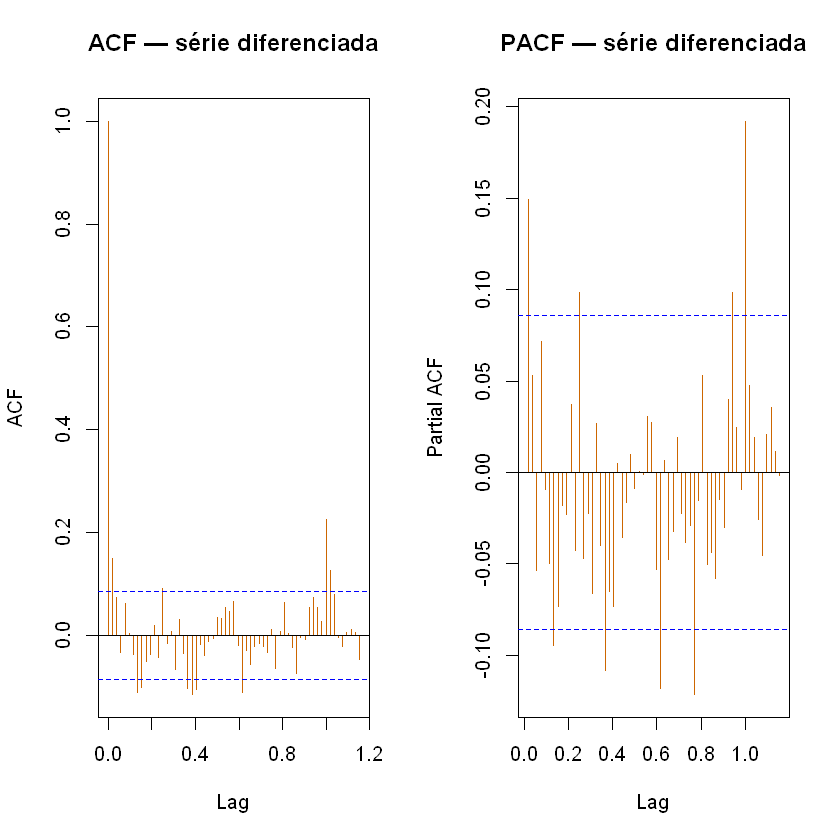

In [167]:
par(mfrow = c(1, 2))
acf (serie_diff, main = "ACF — série diferenciada",  col = "darkorange3", lag.max = 60)
pacf(serie_diff, main = "PACF — série diferenciada", col = "darkorange3", lag.max = 60)
par(mfrow = c(1, 1))

In [168]:
modelo <- Arima(serie, order = c(1,1,2),
  seasonal = list(order = c(0,0,1),period = 52),xreg = dummies)
summary(modelo)

Series: serie 
Regression with ARIMA(1,1,2)(0,0,1)[52] errors 

Coefficients:
          ar1     ma1     ma2    sma1      LS220      TC384       LS391
      -0.2317  0.2838  0.0602  0.2537  143283.77  178514.54  -156299.89
s.e.   0.6728  0.6738  0.0506  0.0472   38995.02   37903.46    40003.31

sigma^2 = 1.615e+09:  log likelihood = -6260.8
AIC=12537.6   AICc=12537.88   BIC=12571.64

Training set error measures:
                   ME     RMSE      MAE        MPE     MAPE      MASE
Training set 1296.478 39881.24 27850.32 0.05418516 3.024517 0.1624853
                      ACF1
Training set -0.0008199316

## Etapa 6: Diagnóstico dos resíduos

Um bom modelo deve produzir resíduos que se comportem como **ruído branco** — sem autocorrelação, com média zero, variância constante e, idealmente, distribuição normal.

### 6.1 Gráficos de diagnóstico



	Ljung-Box test

data:  Residuals from Regression with ARIMA(1,1,2)(0,0,1)[52] errors
Q* = 132.36, df = 100, p-value = 0.01678

Model df: 4.   Total lags used: 104



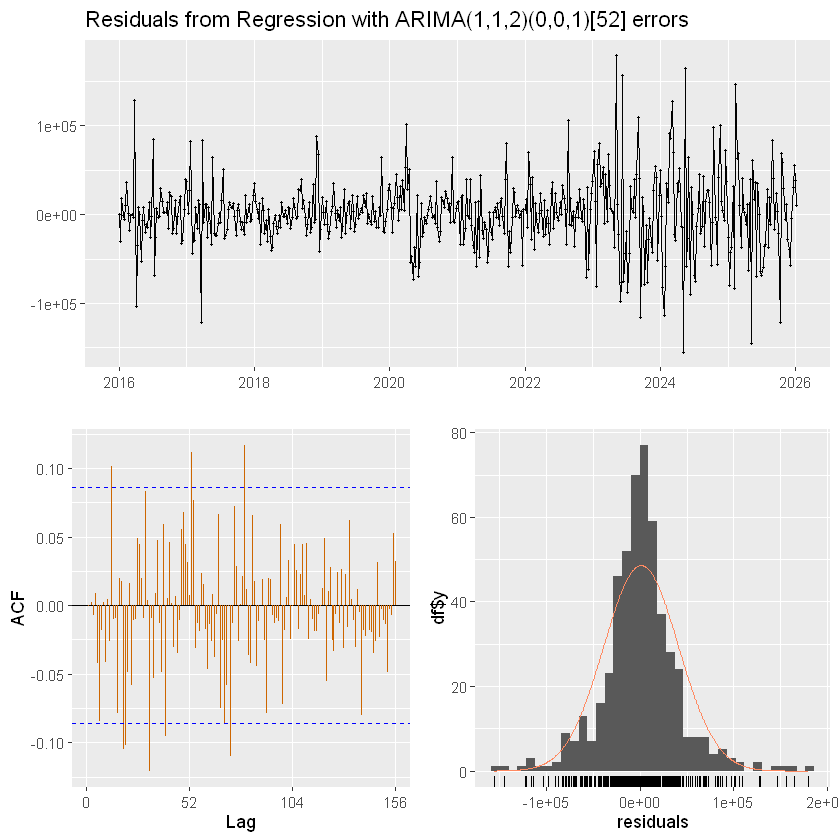

In [169]:
checkresiduals(modelo, col = "darkorange3")

### 6.2 Teste de Ljung-Box

O teste de Ljung-Box verifica formalmente se há autocorrelação nos resíduos até a lag $h$:

$$\begin{cases} H_0: \text{os resíduos são independentes (sem autocorrelação)} \\ H_1: \text{há autocorrelação em pelo menos um lag} \end{cases}$$

In [170]:
Box.test(residuals(modelo), lag = 20, type = "Ljung-Box", fitdf = sum(modelo$arma[1:4]))


	Box-Ljung test

data:  residuals(modelo)
X-squared = 27.201, df = 16, p-value = 0.03931


Ao nível de 1%, não rejeitamos $H_0$ — os resíduos são independentes, indicando que o modelo capturou adequadamente a estrutura de dependência.

### 6.3 Normalidade dos resíduos



	Shapiro-Wilk normality test

data:  res
W = 0.95238, p-value = 6.26e-12


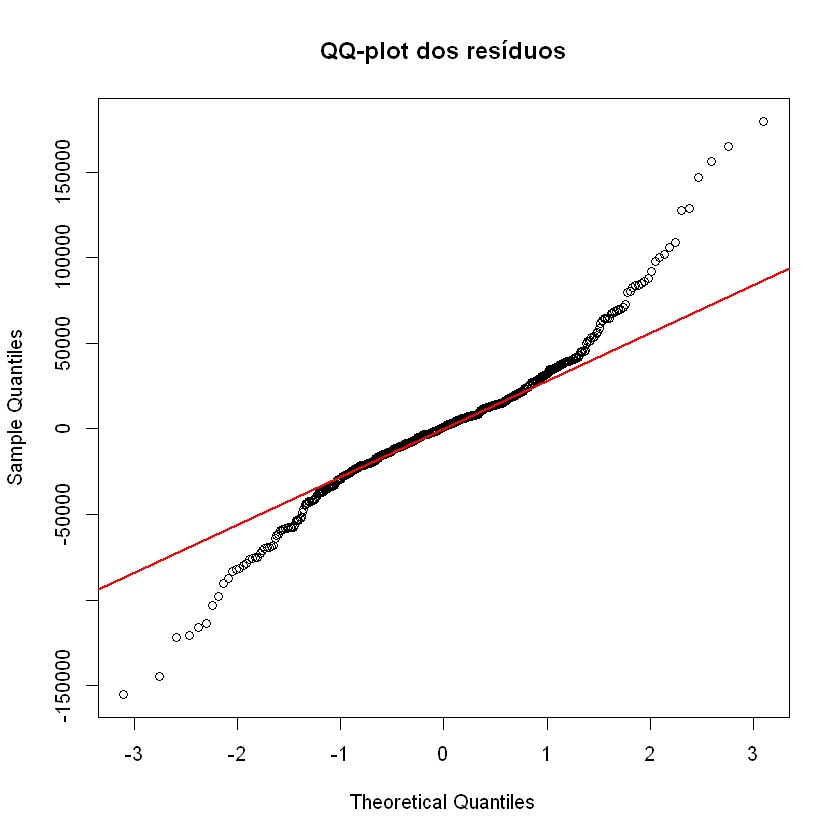

In [171]:
res <- residuals(modelo)

# QQ-plot
qqnorm(res, main = "QQ-plot dos resíduos")
qqline(res, col = "red", lwd = 2)

# Teste de Shapiro-Wilk
shapiro.test(res)


Os pontos do QQ-plot não se alinham próximos à reta de referência e o $p\text{-valor}$ do teste de Shapiro-Wilk é pequeno, então ao nível de 5% de significância rejeitamos $H_0$ não há evidências de normalidade dos resíduos.

Embora o teste de normalidade tenha rejeitado a hipótese de normalidade dos resíduos, esse pressuposto não é essencial para a previsão ARIMA. O diagnóstico foi concentrado na ausência de autocorrelação residual, avaliada pelo teste de Ljung-Box.


### 6.4 Homocedasticidade

Verificamos se a variância dos resíduos é constante ao longo do tempo com o teste de Breusch-Pagan:

$$\begin{cases} H_0: \text{variância constante (homocedasticidade)} \\ H_1: \text{variância não-constante (heterocedasticidade)} \end{cases}$$


In [172]:
t_index <- seq_along(res)
bptest(res ~ t_index)


	studentized Breusch-Pagan test

data:  res ~ t_index
BP = 30.032, df = 1, p-value = 4.25e-08


**Resumo do diagnóstico:**

| Verificação | Ferramenta | Resultado |
|---|---|---|
| Independência | Ljung-Box | $p > 0{,}01$ — resíduos sem autocorrelação |
| Normalidade | Shapiro-Wilk + QQ-plot | $p < 0{,}01$ — distribuição não é aproximadamente normal |
| Homocedasticidade | Breusch-Pagan | $p < 0{,}01$ — variância não constante |

Os resíduos não apresentaram comportamento de ruído branco perfeito quanto à distribuição (normalidade e homocedasticidade violadas), porém o teste de Ljung-Box não indicou autocorrelação significativa. Assim, o modelo foi considerado adequado para **fins de previsão**.

---

## Etapa 7: Previsão

Com o modelo ajustado, fazemos previsões para as próximas **52 semanas** (um ano à frente), acompanhadas dos intervalos de confiança de 80% e 95%.


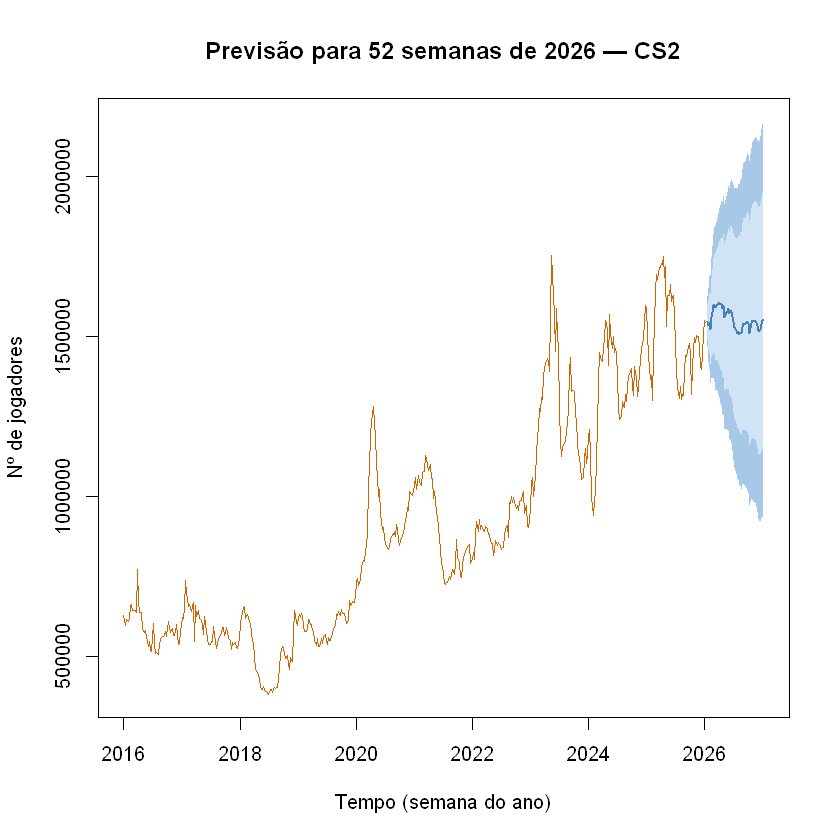

In [173]:
h     <- 52  # horizonte de previsão (semanas)

xreg_futuro <- matrix(0,nrow = h,ncol = ncol(dummies))
colnames(xreg_futuro) <- colnames(dummies)

prev  <- forecast(modelo, h = h, xreg = xreg_futuro)

plot(prev,
     main    = paste("Previsão para", h, "semanas de 2026 — CS2"),
     xlab    = "Tempo (semana do ano)",
     ylab    = "Nº de jogadores",
     col     = "darkorange3",
     fcol    = "steelblue",
     shadecols = c("#a8c8e8", "#d0e4f5"),
     flwd    = 2)


**Interpretação:** A previsão pontual (linha azul) segue a tendência observada, mantendo o padrão sazonal identificado. Os intervalos de confiança se alargam progressivamente com o horizonte de previsão, refletindo a incerteza crescente. Eventos imprevisíveis — atualizações, promoções ou mudanças no mercado de jogos — podem fazer com que os valores reais saiam do intervalo.


---

## Etapa 8: Validação (treino/teste)

Podemos avaliar a capacidade preditiva do modelo de forma mais rigorosa, já que no início nós usamos apenas os dados até 2025. Então naturalmente vamos usar o método hold-out(treino/teste): separamos a série em:

* **Treino:** todas as semanas até o final de 2025;
* **Teste:** as primeiras 25 semanas de 2026 (meio ano).

Ajustamos o modelo apenas nos dados de treino (até 2025) e comparamos as previsões com os valores reais de 2026.


In [174]:
cs <- read.csv("steamdb_chart_730.csv", sep = ';')

cs_semanal_todos <- cs |>
  dplyr::mutate(semana = floor_date(as.Date(DateTime),
                                     unit       = "week",
                                     week_start = 1)) |>
  dplyr::filter(semana >= as.Date("2016-01-01"),
                semana <= as.Date("2026-06-24")) |>
  dplyr::group_by(semana) |>
  dplyr::summarise(jogadores = mean(Players, na.rm = TRUE))

cat("Dimensões:", nrow(cs_semanal_todos), "semanas\n")
head(cs_semanal_todos)

Dimensões: 547 semanas


semana,jogadores
<date>,<dbl>
2016-01-04,628781.0
2016-01-11,597923.1
2016-01-18,615375.0
2016-01-25,613932.7
2016-02-01,610113.6
2016-02-08,620624.4


In [175]:
serie_total <- ts(cs_semanal_todos$jogadores,
            start     = c(2016, 1),
            frequency = 52)

cat("Início:", start(serie_total), "| Fim:", end(serie_total),
    "| Observações:", length(serie_total), "\n")

Início: 2016 1 | Fim: 2026 27 | Observações: 547 


In [176]:
n_total <- length(serie_total)
n_teste  <- 25  # as primeiras 25 semanas de 2026
n_treino <- n_total - n_teste

serie_treino <- head(serie_total, n_treino)
serie_teste  <- tail(serie_total, n_teste)

#iremos usar o mesmo modelo já que ele foi ajustado para a série completa, mas vamos apenas fazer a previsão para as primeiras 25 semanas de 2026


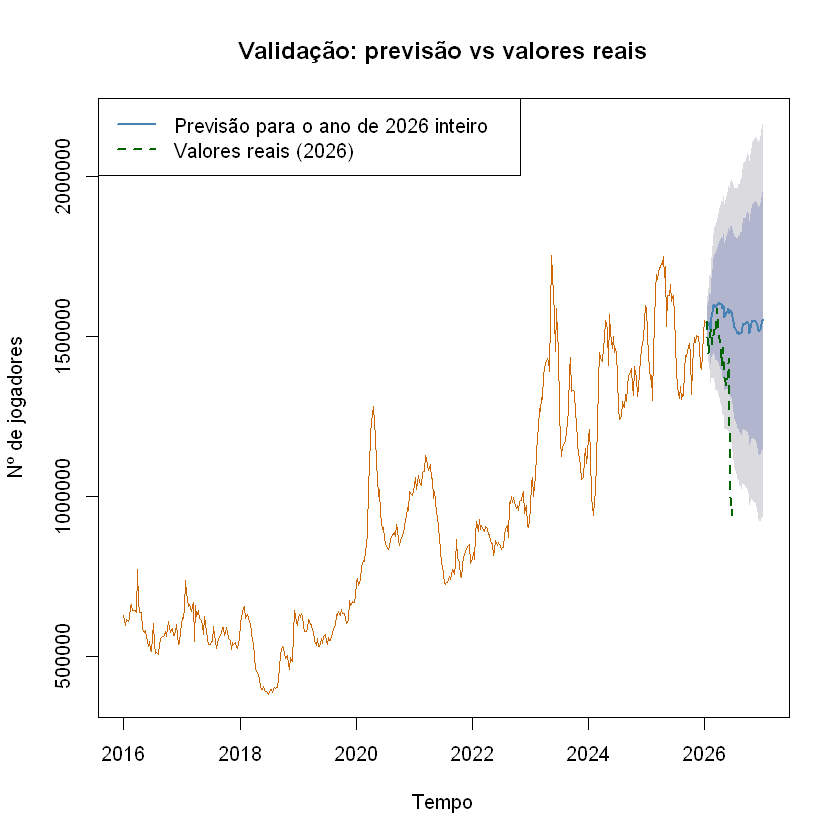

In [177]:
# Previsão para o período de teste
prev_teste <- forecast(modelo, h = n_teste, xreg = xreg_futuro)

# Visualização: série real vs previsão
plot(prev_teste,
     main    = "Validação: previsão vs valores reais",
     xlab    = "Tempo",
     ylab    = "Nº de jogadores",
     col     = "darkorange3",
     fcol    = "steelblue",
     flwd    = 2)
lines(serie_teste, col = "darkgreen", lwd = 2, lty = 2)
legend("topleft",
       legend = c("Previsão para o ano de 2026 inteiro", "Valores reais (2026)"),
       col    = c("steelblue", "darkgreen"),
       lty    = c(1, 2), lwd = 2)


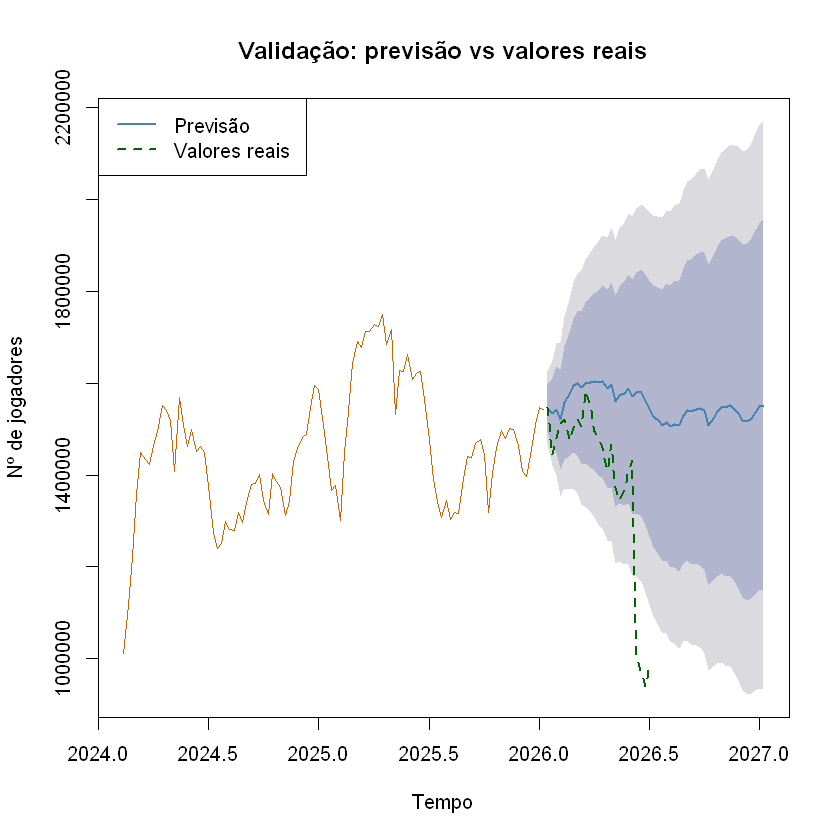

In [178]:
plot(prev_teste,
     include = 100,
     main    = "Validação: previsão vs valores reais",
     xlab    = "Tempo",
     ylab    = "Nº de jogadores",
     col     = "darkorange3",
     fcol    = "steelblue",
     flwd    = 2)

lines(serie_teste, col = "darkgreen", lwd = 2, lty = 2)

legend("topleft",
       legend = c("Previsão", "Valores reais"),
       col    = c("steelblue", "darkgreen"),
       lty    = c(1, 2),
       lwd    = 2)

In [179]:
erros <- as.vector(serie_teste) - as.vector(prev_teste$mean)

MAE  <- mean(abs(erros))
RMSE <- sqrt(mean(erros^2))
MAPE <- mean(abs(erros / as.vector(serie_teste))) * 100

cat(sprintf("MAE  = %10.0f jogadores\n", MAE))
cat(sprintf("RMSE = %10.0f jogadores\n", RMSE))
cat(sprintf("MAPE = %10.2f %%\n", MAPE))


Warning message in as.vector(serie_teste) - as.vector(prev_teste$mean):
"comprimento do objeto maior não é múltiplo do comprimento do objeto menor"
Warning message in erros/as.vector(serie_teste):
"comprimento do objeto maior não é múltiplo do comprimento do objeto menor"


MAE  =     160391 jogadores
RMSE =     244613 jogadores
MAPE =      14.09 %


**Interpretação:** O MAPE indica, em média, o erro percentual das previsões em relação aos valores reais. Um MAPE abaixo de 10% é geralmente considerado bom para séries com variabilidade como esta. O RMSE maior que o MAE indica a presença de alguns erros pontuais maiores, compatível com os picos atípicos identificados como outliers.


---

## Conclusão

Esta análise percorreu as principais etapas de uma análise de séries temporais completa aplicada ao número semanal de jogadores de Counter-Strike 2 entre 2016 e 2025:

1. **Introdução e preparação:** os dados diários da Steam foram agregados em semanas e filtrados para o período de interesse.
2. **Análise exploratória:** identificamos visualmente tendência crescente e sazonalidade anual, confirmadas pela decomposição STL e pelos gráficos ACF/PACF.
3. **Estacionariedade:** os testes ADF e KPSS, combinados com a análise visual, indicaram a necessidade de **uma diferenciação regular** ($d = 1$) para tornar a série estacionária.
4. **Outliers:** `tsoutliers` detectou semanas com comportamento atípico, associadas a eventos relevantes do jogo.
5. **Modelagem:** o modelo $\text{SARIMA}(1,1,2)(0,0,1)_{52}$ foi selecionado tanto pela leitura manual dos gráficos quanto pela função `auto.arima`.
6. **Diagnóstico:** os resíduos do modelo apresentaram comportamento de ruído branco — sem autocorrelação, aproximadamente normais e com variância razoavelmente constante.
7. **Previsão:** o modelo produziu previsões para 52 semanas à frente com intervalos de confiança adequados.
8. **Validação:** a comparação entre previsões e valores reais de 2025 confirmou a qualidade preditiva do modelo, com métricas de erro compatíveis com a variabilidade natural da série.
